In [33]:
import os
from time import time

import cv2

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

from sklearn.utils import shuffle

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Input
layers = tf.keras.layers


In [34]:
def display_history(history, names, title):
    plt.figure()
    plt.title(title)
    for name in names:
        plt.plot(history.history[name], label=name)
    # plt.plot(history.history[names[0]], label=names[0])
    # plt.plot(history.history[names[1]], label=names[1])
    plt.xlabel("Epochs")
    plt.ylabel(names[0])
    plt.legend()
    plt.show()

def predict_random(model, data_x, data_y, image_size = None):
    choose = np.random.randint(0, data_x.shape[0])
    if image_size is None:
        plt.imshow(data_x[choose], cmap='gray')
    else:
        plt.imshow(data_x[choose].reshape(*image_size), cmap='gray')
    predictions = model.predict(data_x)
    plt.title(f'Predicted Object: {np.argmax(predictions[choose])} | Real Object: {np.argmax(data_y[choose])}')
    # plt.title(f'Predicted Object: {int_to_str[np.argmax(predictions[choose])]} | Real Object: {int_to_str[np.argmax(data_y[choose])]}')

def predict(model, X_train, y_train, X_test, y_test, batch_size=64, epochs=40, val_split=0.2, image_size = None):
    # history = model.fit(x=X_train, y=y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_test, y_test), callbacks=callbacks)
    loss_labels = ['loss', 'val_loss']
    acc_labels = ['accuracy', 'val_accuracy']
    if isinstance(val_split, float):
        if val_split == 0: 
            loss_labels = loss_labels[:1]
            acc_labels = acc_labels[:1]
        history = model.fit(x=X_train, y=y_train, batch_size=batch_size, epochs=epochs, validation_split=val_split)
    elif isinstance(val_split, tuple):
        history = model.fit(x=X_train, y=y_train, batch_size=batch_size, epochs=epochs, validation_data=val_split)
    display_history(history, loss_labels, "Loss")
    display_history(history, acc_labels, "Accuracy")
    model.evaluate(X_test, y_test)
    predict_random(model, X_test, y_test, image_size)

## Prac 07.1

In this homework, you are going to use the code from ```TrafficSignsClassification``` notebook and create your own traffic sign classifier.


### Step 1
Use the data from ```data/subset_homework``` folder and visualize some examples. How many images are there for each class?


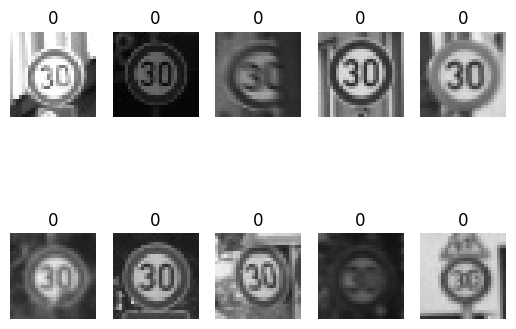

In [35]:
folder = 'data/subset_homework/'

# Load traffic sign class 0
fnames_0 = os.listdir(os.path.join(folder, 'class_id_0'))
images_0 = [cv2.imread(os.path.join(folder, 'class_id_0', f), cv2.IMREAD_UNCHANGED) for f in fnames_0]
labels_0 = [0] * len(images_0)

for cnt, idx in enumerate(np.random.randint(0, len(images_0), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images_0[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels_0[idx]), plt.axis(False)

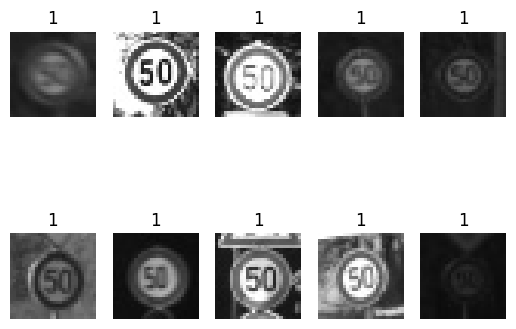

In [36]:
# Load traffic sign class 1
fnames_1 = os.listdir(os.path.join(folder, 'class_id_1'))
images_1 = [cv2.imread(os.path.join(folder, 'class_id_1', f), cv2.IMREAD_UNCHANGED) for f in fnames_1]
labels_1 = [1] * len(images_1)

for cnt, idx in enumerate(np.random.randint(0, len(images_1), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images_1[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels_1[idx]), plt.axis(False)

In [37]:
print('Num samples class_0', len(images_0))
print('Num samples class_1', len(images_1))

Num samples class_0 2220
Num samples class_1 2250


In [38]:
# Put both classes together and shuffle the data
images = images_0 + images_1
labels = labels_0 + labels_1
images, labels = shuffle(images, labels)

images = np.array(images)
labels = np.array(labels)

image_size = images.shape[1:]
print('Images', images.shape)
print('Labels', labels.shape)

Images (4470, 28, 28)
Labels (4470,)


In [39]:
start = time()
pixels = np.array([image.flatten() for image in images])/255
stop = time()

print('Shape', pixels.shape)
print('Elapsed time', stop - start)

Shape (4470, 784)
Elapsed time 0.014727592468261719


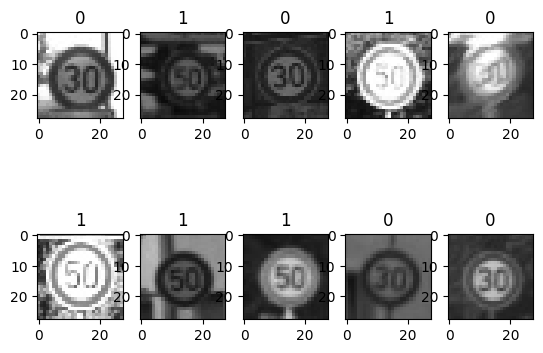

In [40]:
for cnt, idx in enumerate(np.random.randint(0, len(images), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels[idx])


### Step 2
Run the training with one single neuron (as we did in the lecture). What accuracy can you achieve?


In [41]:
inputs = Input(shape=(pixels.shape[1], ))
inputs = Dense(pixels.shape[1], activation="linear")(inputs)
outputs = Dense(1, activation="linear")(inputs)
model = Model(inputs, outputs)

model.compile(optimizer ='adam', loss = 'mean_squared_error', metrics=["accuracy"])

model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ keras_tensor_42CLONE            │ (None, 784)            │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │           785 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 785 (3.07 KB)

 Trainable params: 785 (3.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 887us/step - accuracy: 0.4984 - loss: 0.3498 
Epoch 2/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 887us/step - accuracy: 0.6002 - loss: 0.2484
Epoch 3/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 902us/step - accuracy: 0.6660 - loss: 0.2112
Epoch 4/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 890us/step - accuracy: 0.7074 - loss: 0.1894
Epoch 5/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7405 - loss: 0.1708
Epoch 6/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 885us/step - accuracy: 0.7796 - loss: 0.1547
Epoch 7/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 897us/step - accuracy: 0.7987 - loss: 0.1436
Epoch 8/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 884us/step - accuracy: 0.8215 - loss: 0.1329
Epoch 9/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 890us/step - accuracy: 0.8403 - loss: 0.1246
Epoch 10/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 903us/step - accuracy: 0.8546 - loss: 0.1181
Epoch 11/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 914us/step - accuracy: 0.8709 - loss: 0.1138
Epoch 12/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 869us/step 

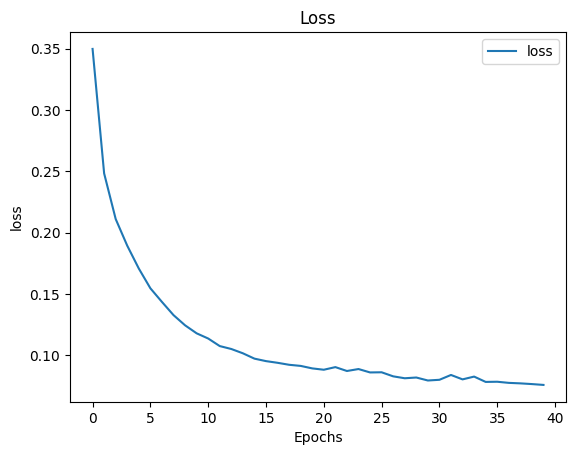

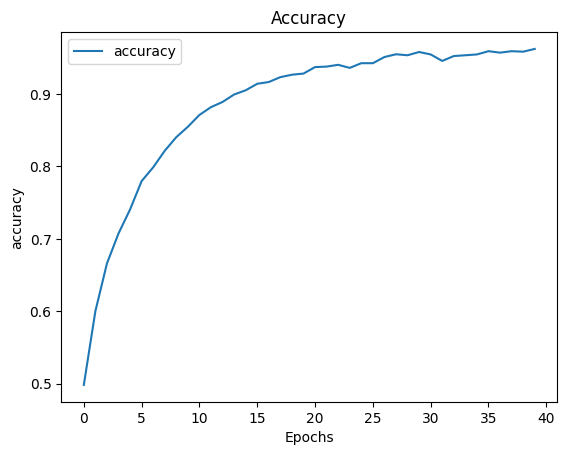

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 732us/step - accuracy: 0.9553 - loss: 0.0767
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 561us/step


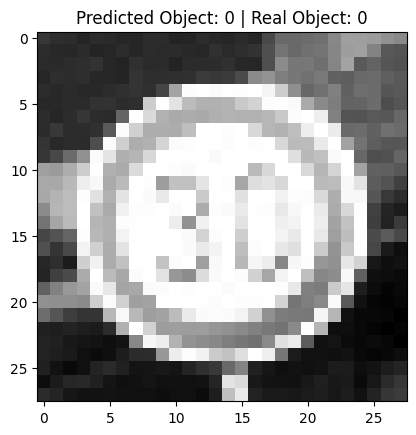

In [42]:
predict(model, pixels, labels, pixels, labels, batch_size=64, epochs=40, val_split=0.0, image_size=image_size)


### Step 3
Make further modifications to improve the accuracy (e.g. add more neurons, more layers, etc.). What is the maximum accuracy you can achieve?

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 784)            │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 392)            │       307,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │           393 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 923,553 (3.52 MB)

 Trainable params: 923,553 (3.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5072 - loss: 8.9765 
Epoch 2/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6324 - loss: 0.2345
Epoch 3/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7197 - loss: 0.1848
Epoch 4/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7906 - loss: 0.1490
Epoch 5/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8456 - loss: 0.1220
Epoch 6/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8837 - loss: 0.1045
Epoch 7/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9174 - loss: 0.0957
Epoch 8/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9002 - loss: 0.1074
Epoch 9/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9331 - loss: 0.0929
Epoch 10/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9327 - loss: 0.0936
Epoch 11/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9237 - loss: 0.0967
Epoch 12/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9172 - l

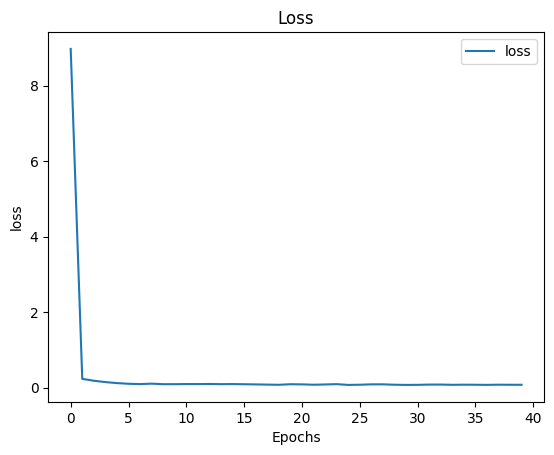

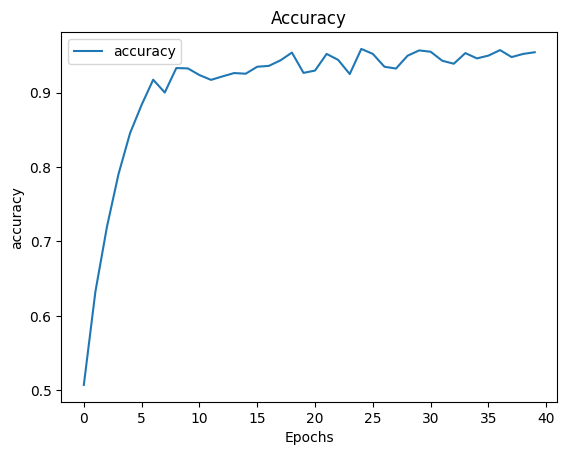

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9541 - loss: 0.0746  
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 973us/step


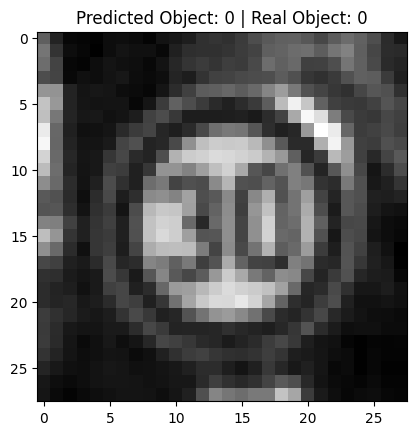

In [43]:
inputs = Input(shape=(pixels.shape[1], ))
x = Dense(pixels.shape[1], activation="linear")(inputs)
x = Dense(pixels.shape[1]//2, activation="linear")(x)
outputs = Dense(1, activation="linear")(x)
model = Model(inputs, outputs)

model.compile(optimizer ='adam', loss = 'mean_squared_error', metrics=["accuracy"])

model.summary()

predict(model, pixels, labels, pixels, labels, batch_size=64, epochs=40, val_split=0.0, image_size=image_size)

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 784)            │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 392)            │       307,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 196)            │        77,028 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 1)              │           197 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,385 (3.82 MB)

 Trainable params: 1,000,385 (3.82 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4998 - loss: 14.7062
Epoch 2/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5526 - loss: 0.2695
Epoch 3/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6257 - loss: 0.2295
Epoch 4/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7058 - loss: 0.1915
Epoch 5/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7649 - loss: 0.1628
Epoch 6/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8186 - loss: 0.1379
Epoch 7/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8421 - loss: 0.1264
Epoch 8/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8779 - loss: 0.1182
Epoch 9/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9116 - loss: 0.1026
Epoch 10/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9257 - loss: 0.0954
Epoch 11/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9204 - loss: 0.1002
Epoch 12/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9188 - l

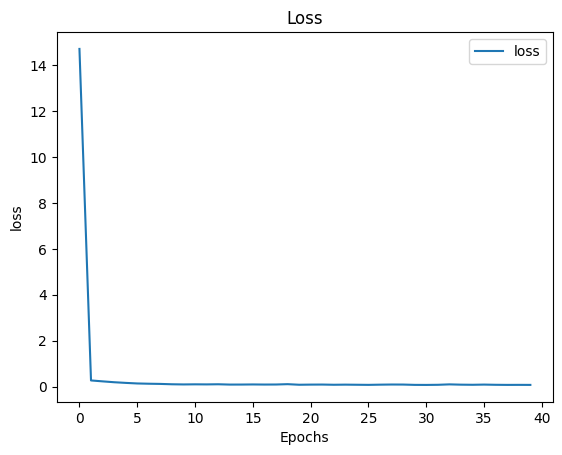

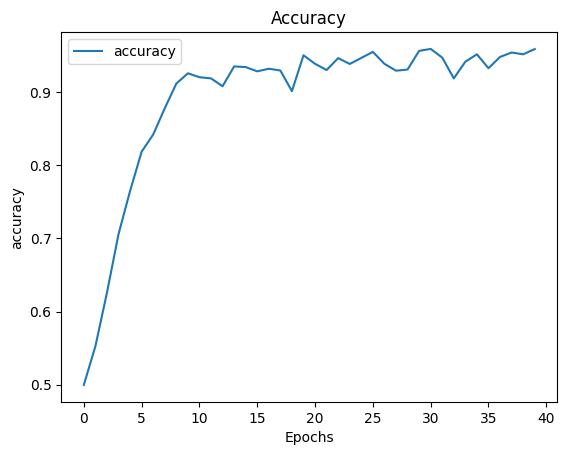

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9653 - loss: 0.0760  
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


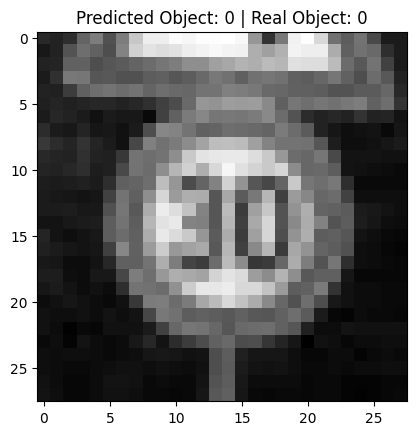

In [44]:
inputs = Input(shape=(pixels.shape[1], ))
x = Dense(pixels.shape[1], activation="linear")(inputs)
x = Dense(pixels.shape[1]//2, activation="linear")(x)
x = Dense(pixels.shape[1]//4, activation="linear")(x)
outputs = Dense(1, activation="linear")(x)
model = Model(inputs, outputs)

model.compile(optimizer ='adam', loss = 'mean_squared_error', metrics=["accuracy"])

model.summary()

predict(model, pixels, labels, pixels, labels, batch_size=64, epochs=40, val_split=0.0, image_size=image_size)

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 784)            │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1568)           │     1,230,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 392)            │       615,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 196)            │        77,028 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │           197 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,538,593 (9.68 MB)

 Trainable params: 2,538,593 (9.68 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4998 - loss: 24.1543
Epoch 2/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5186 - loss: 0.2878
Epoch 3/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5812 - loss: 0.2489
Epoch 4/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6597 - loss: 0.2127
Epoch 5/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7257 - loss: 0.1796
Epoch 6/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7787 - loss: 0.1588
Epoch 7/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8284 - loss: 0.1349
Epoch 8/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8499 - loss: 0.1307
Epoch 9/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8714 - loss: 0.1224
Epoch 10/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9067 - loss: 0.1075
Epoch 11/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9020 - loss: 0.1088
Epoch 12/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy

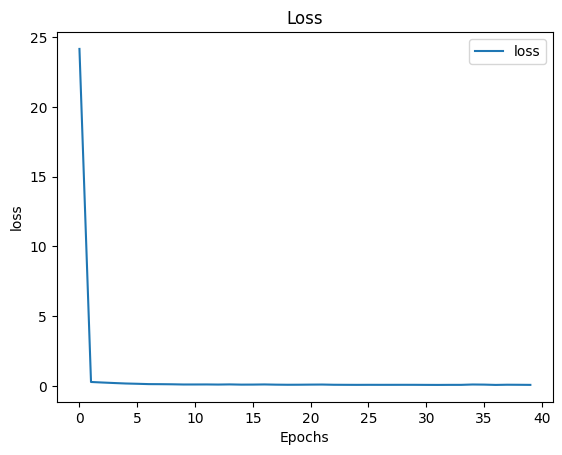

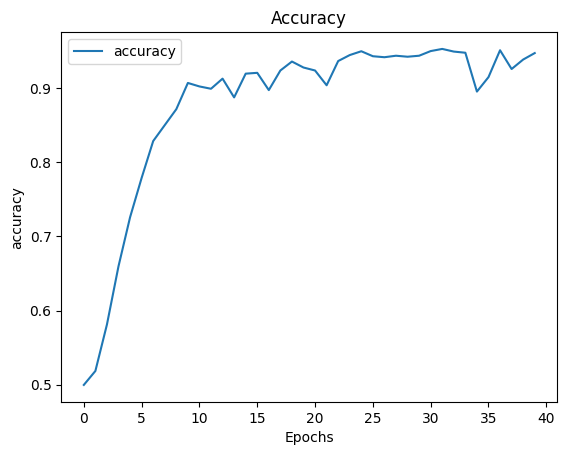

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9570 - loss: 0.0724
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


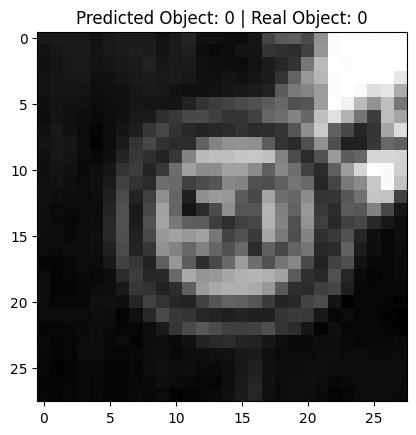

In [45]:
inputs = Input(shape=(pixels.shape[1], ))
x = Dense(pixels.shape[1], activation="linear")(inputs)
x = Dense(pixels.shape[1]*2, activation="linear")(x)
x = Dense(pixels.shape[1]//2, activation="linear")(x)
x = Dense(pixels.shape[1]//4, activation="linear")(x)
outputs = Dense(1, activation="linear")(x)
model = Model(inputs, outputs)

model.compile(optimizer ='adam', loss = 'mean_squared_error', metrics=["accuracy"])

model.summary()

predict(model, pixels, labels, pixels, labels, batch_size=64, epochs=40, val_split=0.0, image_size=image_size)

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_22 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 256)            │       401,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,369 (1.53 MB)

 Trainable params: 402,305 (1.53 MB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5311 - loss: 6.5074 
Epoch 2/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5716 - loss: 0.6713
Epoch 3/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6465 - loss: 0.3927
Epoch 4/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7018 - loss: 0.2669
Epoch 5/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7506 - loss: 0.2205
Epoch 6/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7792 - loss: 0.1902
Epoch 7/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8150 - loss: 0.1518
Epoch 8/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8210 - loss: 0.1638
Epoch 9/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8443 - loss: 0.1306
Epoch 10/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8640 - loss: 0.1193
Epoch 11/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8685 - loss: 0.1136
Epoch 12/40
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy

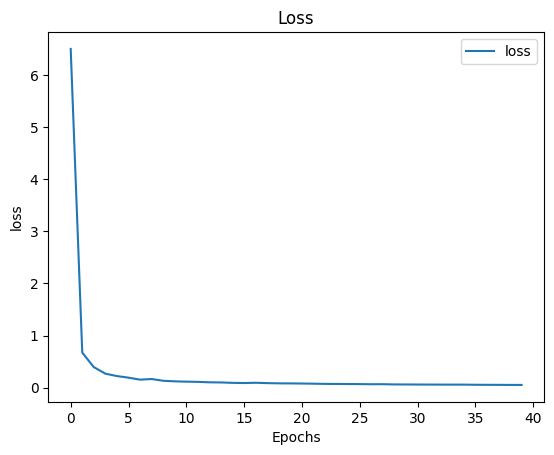

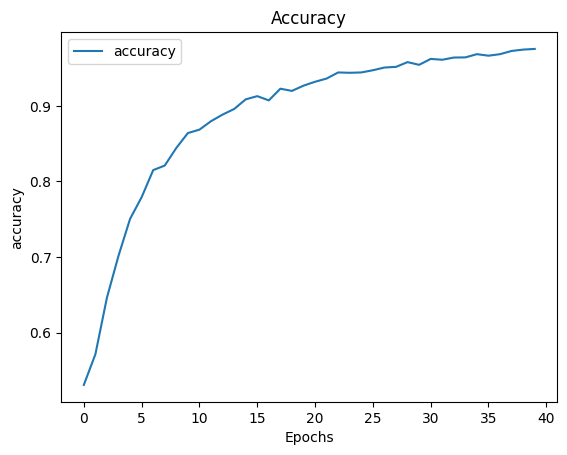

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9975 - loss: 0.0240
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


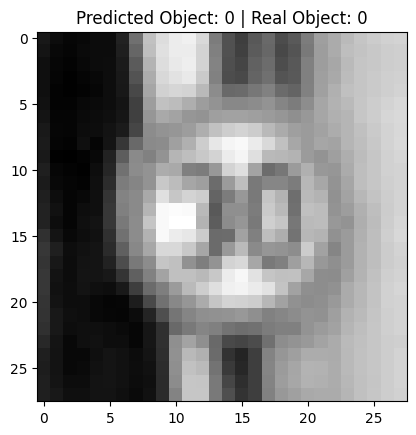

In [51]:
inputs = Input(shape=(*images.shape[1:], 1))
# inputs = Dense(pixels.shape[1], activation="linear")(inputs)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(4, 4)(x)

x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='linear')(x)
# outputs = Dense(1, activation="linear")(inputs)
model = Model(inputs, outputs)

model.compile(optimizer ='adam', loss = 'mean_squared_error', metrics=["accuracy"])

model.summary()

predict(model, images, labels, images, labels, batch_size=64, epochs=40, val_split=0.0, image_size=image_size)

# Prac 07.2

In this homework you are going to inspect the GTSDB (German Traffic Sign Detection Benchmark) dataset. The dataset contains images of various classes of traffic signs used in Germany (and the whole EU). The objective of this homework is to go through the steps described below and to implement the necessary code.

At the end, as usual, there will be a couple of questions for you to answer. In addition, the last section of this homework is optional and, if you chose to do it, you'll earn extra point :-)

### Step 0

Go to the GTSRB dataset official site ([link](https://benchmark.ini.rub.de/gtsrb_dataset.html)) to learn more about the dataset.

### Step 1

Download the dataset ([link](https://www.kaggle.com/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign)) and unzip it.

### Step 2

For this homework, you will be working with the training set. Check out the `Train.csv`, open it and see what it contains. Load the dataset and plot random samples.

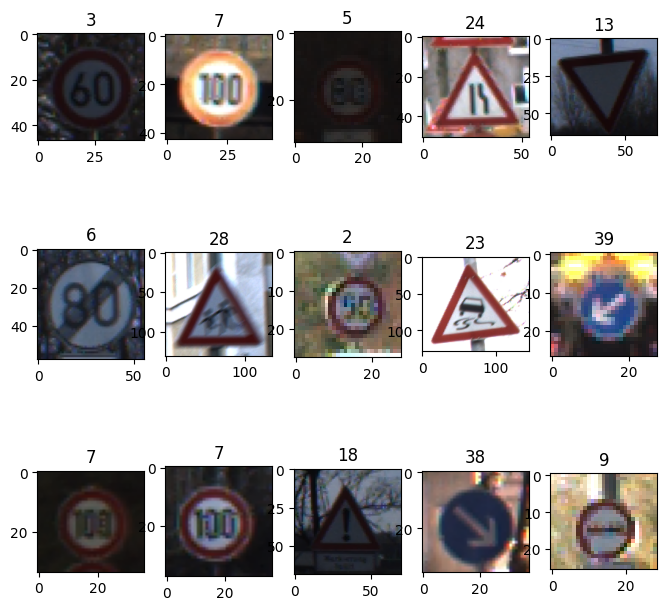

In [56]:
# Load the training labels
root = 'archive/' # Path to the dataset location, e.g., '/data/janko/dataset/GTSRB'
data = pd.read_csv(os.path.join(root, 'Train.csv'))

# Number of training samples (amount of samples in data)
num_samples = len(data)

# Show random data samples
fig, axes = plt.subplots(3, 5, figsize=(8, 8))
axes = axes.flatten()
for ii in range(15):
    # Get random index
    idx = np.random.randint(0, num_samples)
    # Load image
    img = cv2.imread(os.path.join(root, data.iloc[idx]['Path']))
    # Convert image to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Show image
    axes[ii].imshow(img), axes[ii].set_title(data.iloc[idx]['ClassId'])

### Step 3

Inspect the dataset by computing and plotting the per-class histogram.

In [59]:
# Extract class identifiers
# Hint: Check the csv 
ids = data['ClassId']

Compute the per class histogram. You can use any approach you want (e.g. `numpy`). It's also worth looking at the `Counter` function from the `collections` module ([link](https://docs.python.org/3/library/collections.html#collections.Counter)) ;-)

(Text(0.5, 0, 'Traffic Sign ID'), Text(0, 0.5, 'Counts'))

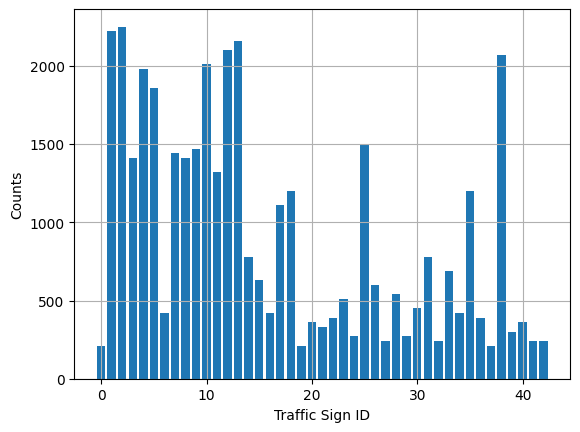

In [64]:
from collections import Counter
hist = Counter(ids)

plt.bar(hist.keys(), hist.values()), plt.grid(True)
plt.xlabel('Traffic Sign ID'), plt.ylabel('Counts')

### Questions

Please answer the following questions:
* Do you consider the dataset to be balanced? If so, why? If not, why?
* Are there any classes that are (significantly) over-represented or under-represeneted?

### Optional

Perform a further analysis on the dataset and draw some conclusion from it.

Hint 1: Unlike MNIST or CIFAR10, this dataset contains images with various spatial resolutions. Is there anything we can tell about the resolution distribution?
Hint 2: What about the brightness distribution? Are there classes there are significantly more bright than others?

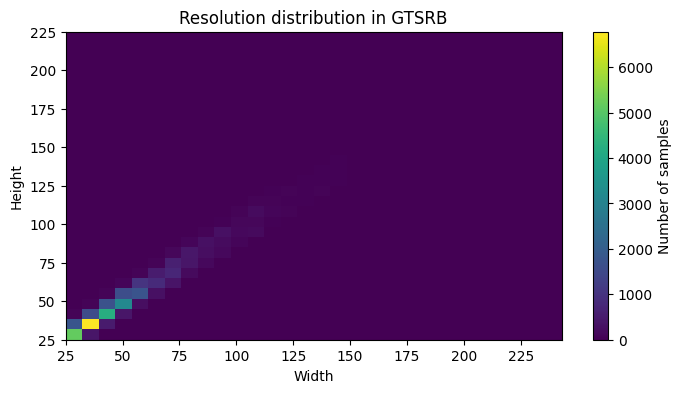

In [66]:
widths = data['Width']
heights = data['Height']

plt.figure(figsize=(8,4))
plt.hist2d(widths, heights, bins=30, cmap='viridis')
plt.colorbar(label='Number of samples')
plt.xlabel('Width')
plt.ylabel('Height')
plt.title('Resolution distribution in GTSRB')
plt.show()


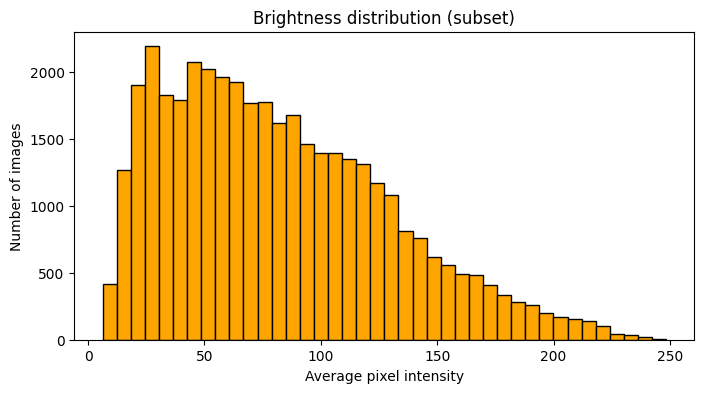

In [69]:
brightness = []
for p in data['Path']:
    img = cv2.imread(os.path.join(root, p))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    brightness.append(np.mean(gray))

plt.figure(figsize=(8,4))
plt.hist(brightness, bins=40, color='orange', edgecolor='black')
plt.title('Brightness distribution (subset)')
plt.xlabel('Average pixel intensity')
plt.ylabel('Number of images')
plt.show()
